# Drug-state prediction: performance, permutation tests, channel subsets

* **Table** full-montage A/B/C performance (per fold + mean), with permutation p-values
* **Figure** channel-subset performance heatmap (balanced accuracy & ROC-AUC, permutation stars)
* **Figure** per-fold balanced-accuracy strip plot across montages

Reads the cross-validated model outputs in `results/models/` and the permutation summaries in `results/permutation/` (produced by `scripts/03_train_models.py` and `scripts/04_channel_subset_models.py`).

In [1]:
import sys, pathlib
for _cand in (pathlib.Path.cwd(), pathlib.Path.cwd().parent):
    if (_cand / "src" / "ketamine_eeg").exists():
        sys.path.insert(0, str(_cand / "src")); break
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from ketamine_eeg import config as c
from ketamine_eeg.plotting import apply_style, fig_width
apply_style()
c.ensure_dirs()
print("ketamine_eeg loaded; figures ->", c.FIGURE_DIR.relative_to(c.PROJECT_ROOT))

ketamine_eeg loaded; figures -> results/figures


In [2]:
full = pd.read_csv(c.RESULTS_MAIN_PATH)
full_perm = pd.read_csv(c.PERM_SUMMARY_MAIN_PATH).set_index("model")
sub = pd.read_csv(c.RESULTS_SUBSET_PATH)
sub_perm = pd.read_csv(c.PERM_SUMMARY_SUBSET_PATH)
print("models:", sorted(full["model"].unique()))
print("subsets:", sorted(sub["subset"].unique()))

models: ['A_bandpower_epoch', 'B_wpli_edges_epoch_sliding', 'C_AplusB_epoch_sliding']
subsets: ['bis_quatro', 'both_lateral', 'left_lateral', 'right_lateral']


## Table: full-montage A/B/C performance
Mean +/- SD balanced accuracy, ROC-AUC and accuracy across the 5 outer folds, with centred two-sided permutation p-values. Saved to `results/tables/main_model_performance.csv`.

In [3]:
label = {c.MODEL_A: "A bandpower (24)", c.MODEL_B: "B wPLI (5673)", c.MODEL_C: "C A+B (5697)"}
rows = []
for m in (c.MODEL_A, c.MODEL_B, c.MODEL_C):
    g = full[full["model"] == m]
    pr = full_perm.loc[m]
    rows.append({
        "model": label[m],
        "bacc_mean": g["balanced_accuracy"].mean(), "bacc_sd": g["balanced_accuracy"].std(),
        "auc_mean": g["roc_auc"].mean(), "auc_sd": g["roc_auc"].std(),
        "acc_mean": g["accuracy"].mean(),
        "p_perm_bacc": float(pr["p_perm_bacc"]), "p_perm_auc": float(pr["p_perm_auc"]),
    })
perf = pd.DataFrame(rows)
perf.to_csv(c.TABLES_DIR / "main_model_performance.csv", index=False)
print("saved results/tables/main_model_performance.csv")
perf.round(4)

saved results/tables/main_model_performance.csv


,model,bacc_mean,bacc_sd,auc_mean,auc_sd,acc_mean,p_perm_bacc,p_perm_auc
0,A bandpower (24),0.7200,0.1423,0.8161,0.1665,0.7181,0.0090,0.0090
1,B wPLI (5673),0.5077,0.1087,0.4874,0.1422,0.5076,0.8222,0.8102
2,C A+B (5697),0.6283,0.0603,0.7311,0.0842,0.6306,0.0110,0.0020


## Figure: channel-subset performance heatmap
Full 62-channel montage vs reduced montages, for feature sets A/B/C. Stars are metric-matched two-sided permutation tests (\*\*\* p<0.001, \*\* p<0.01, \* p<0.05).

saved channel_subsets_heatmap.png


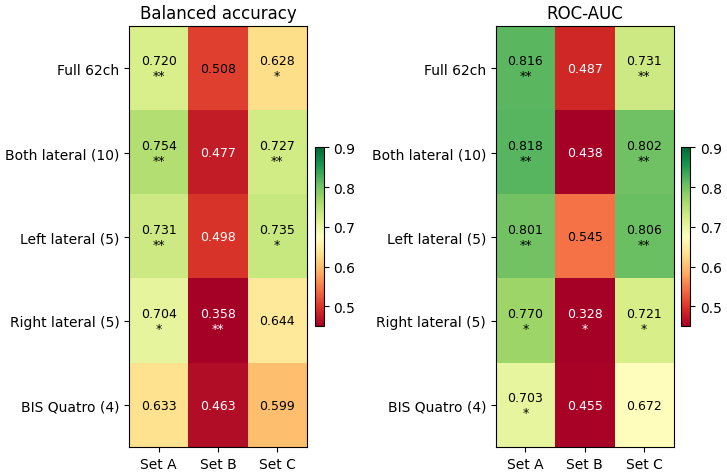

In [4]:
subsets = ["full_62ch", "both_lateral", "left_lateral", "right_lateral", "bis_quatro"]
heat_labels = ["Full 62ch", "Both lateral (10)", "Left lateral (5)", "Right lateral (5)", "BIS Quatro (4)"]
feat_types = ["A", "B", "C"]

def stars(p):
    if pd.isna(p): return ""
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""

bacc = np.full((len(subsets), 3), np.nan); auc = np.full((len(subsets), 3), np.nan)
pb = np.full((len(subsets), 3), np.nan); pa = np.full((len(subsets), 3), np.nan)
for ci, ft in enumerate(feat_types):
    for ri, s in enumerate(subsets):
        if s == "full_62ch":
            g = full[full["model"] == c.FULL_MODEL_MAP[ft]]
            bacc[ri, ci] = g["balanced_accuracy"].mean(); auc[ri, ci] = g["roc_auc"].mean()
            pr = full_perm.loc[c.FULL_MODEL_MAP[ft]]
            pb[ri, ci] = float(pr["p_perm_bacc"]); pa[ri, ci] = float(pr["p_perm_auc"])
        else:
            g = sub[(sub["subset"] == s) & (sub["feat_type"] == ft)]
            bacc[ri, ci] = g["balanced_accuracy"].mean(); auc[ri, ci] = g["roc_auc"].mean()
            pr = sub_perm[(sub_perm["subset"] == s) & (sub_perm["feat_type"] == ft)]
            if len(pr):
                pb[ri, ci] = float(pr["p_perm_bacc"].values[0]); pa[ri, ci] = float(pr["p_perm_auc"].values[0])

fig, axes = plt.subplots(1, 2, figsize=(fig_width("double"), 5))
for ax, mat, pmat, title in [(axes[0], bacc, pb, "Balanced accuracy"), (axes[1], auc, pa, "ROC-AUC")]:
    im = ax.imshow(mat, vmin=0.45, vmax=0.90, cmap="RdYlGn", aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title)
    ax.set_xticks(range(3)); ax.set_xticklabels([f"Set {f}" for f in feat_types])
    ax.set_yticks(range(len(subsets))); ax.set_yticklabels(heat_labels)
    for ri in range(mat.shape[0]):
        for ci in range(mat.shape[1]):
            lab = f"{mat[ri,ci]:.3f}" + (f"\n{stars(pmat[ri,ci])}" if stars(pmat[ri,ci]) else "")
            ax.text(ci, ri, lab, ha="center", va="center", fontsize=9,
                    color="black" if 0.5 < mat[ri,ci] < 0.85 else "white")
fig.tight_layout()
fig.savefig(c.FIGURE_DIR / "channel_subsets_heatmap.png", dpi=300, bbox_inches="tight")
print("saved channel_subsets_heatmap.png")
plt.show()

## Figure: per-fold balanced accuracy across montages

saved channel_subsets_per_fold.png


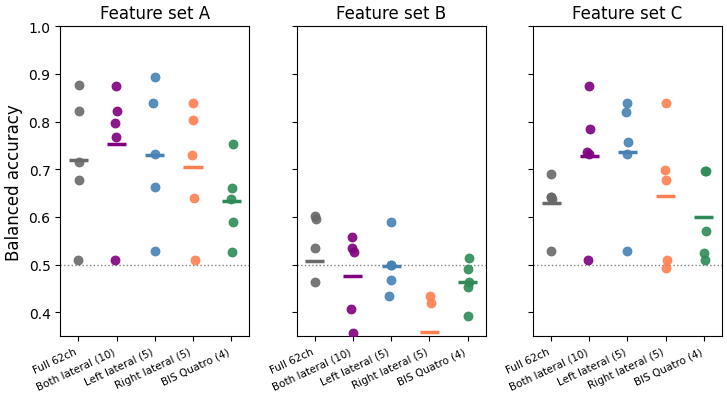

In [5]:
subset_colors = ["dimgrey", "purple", "steelblue", "coral", "seagreen"]
fig, axes = plt.subplots(1, 3, figsize=(fig_width("double"), 4.2), sharey=True)
for ax, ft in zip(axes, feat_types):
    for i, (s, color) in enumerate(zip(subsets, subset_colors)):
        if s == "full_62ch":
            vals = full[full["model"] == c.FULL_MODEL_MAP[ft]]["balanced_accuracy"].values
        else:
            vals = sub[(sub["subset"] == s) & (sub["feat_type"] == ft)]["balanced_accuracy"].values
        jit = (np.random.RandomState(i).rand(len(vals)) - 0.5) * 0.10
        ax.scatter(np.full(len(vals), i) + jit, vals, color=color, s=42, zorder=3, alpha=0.9)
        ax.hlines(vals.mean(), i-0.25, i+0.25, colors=color, linewidths=2.5)
    ax.axhline(0.5, ls=":", color="grey", lw=1)
    ax.set_xticks(range(len(subsets)))
    ax.set_xticklabels(heat_labels, fontsize=7.5, rotation=25, ha="right")
    ax.set_title(f"Feature set {ft}"); ax.set_ylim(0.35, 1.0)
axes[0].set_ylabel("Balanced accuracy")
fig.tight_layout()
fig.savefig(c.FIGURE_DIR / "channel_subsets_per_fold.png", dpi=300, bbox_inches="tight")
print("saved channel_subsets_per_fold.png")
plt.show()